# Libraries

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reading image

In [17]:
img=cv2.imread('test.jpg')

In [18]:
type(img)

numpy.ndarray

In [19]:
img.shape # height , width , channel

(375, 500, 3)

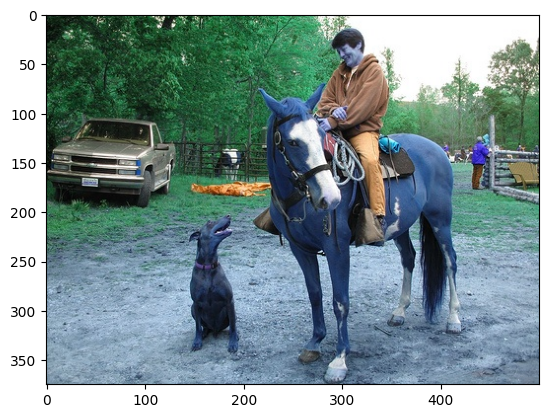

In [20]:
plt.imshow(img)
plt.show()

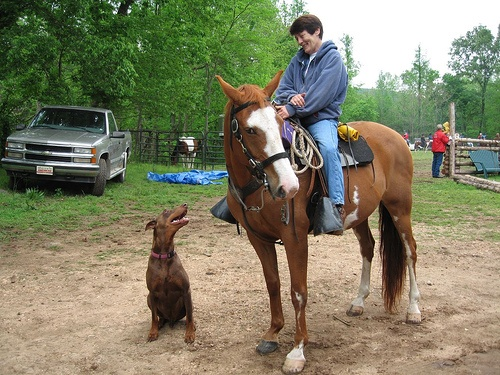

In [21]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Color conversion

In [22]:
img_RGB=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

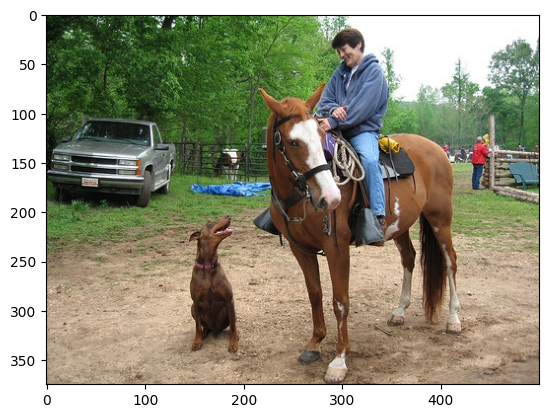

In [23]:
plt.imshow(img_RGB)

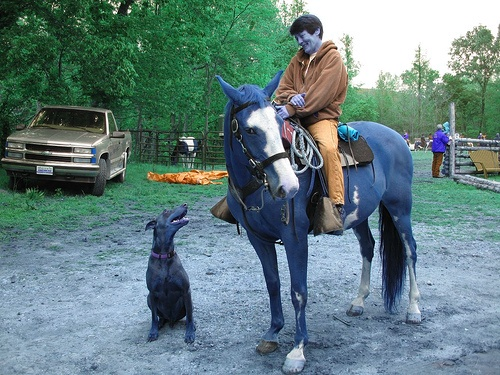

In [24]:
from google.colab.patches import cv2_imshow
cv2_imshow(img_RGB)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
img_GRAY=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

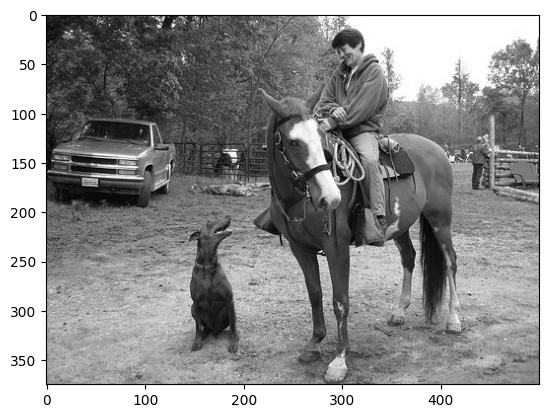

In [26]:
plt.imshow(img_GRAY,cmap='gray')
plt.show()

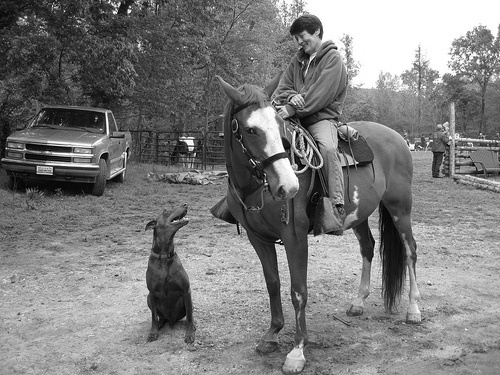

In [28]:
from google.colab.patches import cv2_imshow
cv2_imshow(img_GRAY)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Resizing Image

In [29]:
img_size=cv2.resize(img_RGB,dsize=(416,416)) # width , height

In [30]:
img_size.shape

(416, 416, 3)

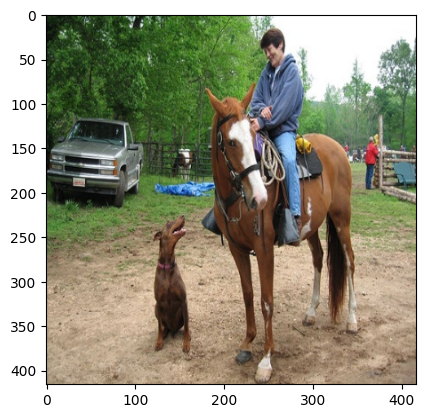

In [31]:
plt.imshow(img_size)
plt.show()

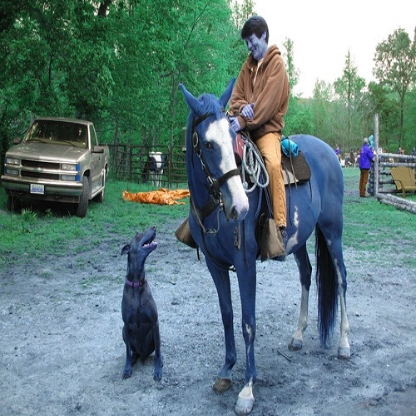

In [33]:
from google.colab.patches import cv2_imshow
cv2_imshow(img_size)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Save image

In [34]:
cv2.imwrite('saved_img.jpg',img_GRAY)

True

## HSV Color Space & Trackbar
- H : This refers to the color type, and it is represented as an angle on a color wheel. The hue component ranges from 0° to 360°, where 0° corresponds to red, 120° to green, and 240° to blue.
  مهتم بجزء معين من اللون
- S : This defines the intensity or purity of the color. A saturation of 0 makes the color a shade of gray, and 100% makes it the purest form of the hue. It ranges from 0 to 1 or 0 to 100%.العمق درجة تشبع اللون
- V : Sometimes called brightness or lightness, it refers to how bright the color is. Value ranges from 0 to 255, where 0 is completely black and 255 is the brightest. درجة اللون فاتح ولا غامق

# Image Processing

In [39]:
# helper function to display gray images
def imshow(img):
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap='gray')
    plt.show()

In [40]:
img = cv2.imread('sudoku.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

imshow(img_gray)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


## blurring

In [ ]:
# blurring image to reduce noise
# try to comment this line and see the difference
# also try to change ksize
img_gray_blur = cv2.blur(img_gray, ksize=(7,7))

imshow(img_gray_blur)

## Filter2D (Convolution Filter)

In [ ]:
image = img_gray_blur.copy()

# Filter2D (Convolution Filter)
kernel = np.ones((5, 5), np.float32) / 25
filtered_image = cv2.filter2D(image, -1, kernel)



# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Filtered Image (Filter2D)', filtered_image)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()


## Gaussian Blur
remove Noise & blur

In [ ]:
# Gaussian Blur
gaussian_blur = cv2.GaussianBlur(image, (5, 5), sigmaX = 0)

# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Gaussian Blur', gaussian_blur)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Median Blur
لحذف salt and paper

In [ ]:
img = cv2.imread('Grey.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Median Blur
median_blur = cv2.medianBlur(img_gray, ksize =5)

# Display results
cv2.imshow('Original Image', img)
cv2.imshow('Median Blur', median_blur)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Bilateral Filter
بيركز على الحواف بيخليها حاده

In [ ]:
# Bilateral Filter
bilateral_filter = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace= 75)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Bilateral Filter', bilateral_filter)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

# Morphological Transformations

In [ ]:
img = cv2.imread('noise.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

imshow(img_gray)


## Erosion
تاكل الحواف

In [ ]:
image = img_gray.copy()
# Erosion
kernel = np.ones((5, 5), np.uint8)
eroded_image = cv2.erode(image, kernel, iterations=4)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Eroded Image', eroded_image)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Dilation
تمدد الحواف

In [ ]:
image = img_gray.copy()
# Dilation
kernel = np.ones((5, 5), np.uint8)
dilated_image = cv2.dilate(image, kernel, iterations=3)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Dilated Image', dilated_image)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Opening (Erosion followed by Dilation)
بياكل الحواف وبعدها يمدد الحواف

In [41]:
image = img_gray.copy()
# Opening (Erosion followed by Dilation)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Opening', opening)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

NameError: name 'img_gray' is not defined

## Closing (Dilation followed by Erosion)
بيمدد الحواف وبعدها بياكل الحواف

In [ ]:
image = img_gray.copy()
# Closing (Dilation followed by Erosion)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Closing', closing)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Sobel X and Sobel Y
بتحدد الحواف اللى فى محور X و Y

In [ ]:
image = img_gray.copy()
# Sobel X and Sobel Y
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Sobel X', sobel_x)
cv2.imshow('Sobel Y', sobel_y)

# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Laplacian
بيركز على المنتصف

In [ ]:
image = img_gray.copy()
# Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_64F)
# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Laplacian', laplacian)
# Wait for a key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Canny
بيحدد الحواف

Canny does use two thresholds (upper and lower):
- If a pixel gradient is higher than the upper threshold, the pixel is accepted as an edge
- If a pixel gradient value is below the lower threshold, then it is rejected.
- If the pixel gradient is between the two thresholds, then it will be accepted only if it is connected to a pixel that is above the upper threshold.

Source: https://docs.opencv.org/3.4/da/d5c/tutorial_canny_detector.html

In [ ]:
image = img_gray.copy()
img_canny = cv2.Canny(img_gray, threshold1=25, threshold2=127)
imshow(img_canny)

# Thresholding (segmentation)

In [ ]:
ret, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
imshow(img_bin)

## Adaptive Threshold
كل بكسل يحصل على عتبة مختلفة حسب إضاءة منطقته القريبة.

In [ ]:
# Apply global thresholding for comparison
_, global_thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Apply adaptive mean thresholding
adaptive_thresh_mean = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                             cv2.THRESH_BINARY, 11, 2)

# Apply adaptive Gaussian thresholding
adaptive_thresh_gaussian = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                                 cv2.THRESH_BINARY, 11, 2)

# Display the images
"""print('Original Image')
imshow(img_gray)
print('Global Thresholding' )
imshow(global_thresh)
print('Adaptive Mean Thresholding' )
imshow(adaptive_thresh_mean)
print('Adaptive Gaussian Thresholding')
imshow(adaptive_thresh_gaussian)"""

# Display the images
cv2.imshow('Original Image', img_gray)
cv2.imshow('Global Thresholding', global_thresh)
cv2.imshow('Adaptive Mean Thresholding', adaptive_thresh_mean)
cv2.imshow('Adaptive Gaussian Thresholding', adaptive_thresh_gaussian)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()


## Otsu

In [ ]:
ret, img_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_OTSU)
imshow(img_otsu)

In [ ]:
ret

In [ ]:
img_invert = 255 - img_otsu
imshow(img_invert)

In [42]:
def imread(img_path):
    img = cv2.imread(img_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def rgb2gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def rgb2bin(img):
    img = rgb2gray(img)
    t, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV)
    return img_bin

def imshow(img, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray')
    plt.show()

In [43]:
img_shapes = imread('nested-shapes.png')
imshow(img_shapes)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


# Find contours
We must convert the image to binary first

In [ ]:
img_shapes_bin = rgb2bin(img_shapes)
imshow(img_shapes_bin)

In [ ]:
contours, _ = cv2.findContours(img_shapes_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

img_copy = img_shapes.copy()
cv2.drawContours(img_copy, contours, -1, (255, 0, 255), 2)
imshow(img_copy)

In [ ]:
contours[4]

In [ ]:
contours[4].shape

## Bounding rect

In [ ]:
(x, y, w, h) = cv2.boundingRect(contours[6])

img_copy = img_shapes.copy()
cv2.rectangle(img_copy, (x, y), (x+w, y+h), (255, 0, 0), 2)
imshow(img_copy)

## Area of Contours

In [ ]:
cv2.contourArea(contours[0])

In [ ]:
if cv2.contourArea(contours[0]) > 2500 :
    print(cv2.contourArea(contours[0]))

## Length of perimeter

In [ ]:
cv2.arcLength(contours[0],True)

# Draw Shapes

In [ ]:
# Create a blank image (black background)
image = np.zeros((512, 512, 3), np.uint8)

##  Draw a Line

In [ ]:
# Draw a Line
start_point = (50, 50)
end_point = (400, 50)
color = (255, 0, 0)  # Blue color in BGR
thickness = 5
cv2.line(image, start_point, end_point, color, thickness)

# Display the image
cv2.imshow('Shapes', image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Draw a Rectangle

In [ ]:
# Draw a Rectangle
top_left = (50, 100)
bottom_right = (400, 250)
color = (0, 255, 0)  # Green color in BGR
thickness = 3
cv2.rectangle(image, top_left, bottom_right, color, thickness)

# Display the image
cv2.imshow('Shapes', image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()

## Draw a Circle

In [ ]:
# Draw a Circle
center = (300, 300)
radius = 50
color = (0, 0, 255)  # Red color in BGR
thickness = -1  # Filled circle
cv2.circle(image, center, radius, color, thickness)

# Display the image
cv2.imshow('Shapes', image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()


## Draw a Polygon

In [ ]:
# Draw a Polygon
points = np.array([[100, 300], [200, 400], [300, 300], [250, 250]], np.int32)
points = points.reshape((-1, 1, 2))  # Required format for polylines
cv2.polylines(image, [points], isClosed=True, color=(255, 0, 255), thickness=3)

# Display the image
cv2.imshow('Shapes', image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()


## Draw Text

In [ ]:
# Draw Text
font = cv2.FONT_HERSHEY_SIMPLEX
text = "OpenCV Drawing"
position = (10, 450)
font_scale = 1
color = (255, 255, 255)  # White color
thickness = 2
cv2.putText(image, text, position, font, font_scale, color, thickness, cv2.LINE_AA)

# Display the image
cv2.imshow('Shapes', image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()

# Camera

In [ ]:
cap=cv2.VideoCapture(0)

In [ ]:
cap.isOpened()

In [ ]:
ret,image = cap.read()

In [ ]:
ret

In [ ]:
image

## Real Live Camera

In [ ]:
cap=cv2.VideoCapture(0)
while cap.isOpened() :
    ret,image=cap.read()
    if ret == False :
        break

    if cv2.waitKey(1)==ord('q'):
        break
    cv2.imshow('video',image)
cap.release()
cv2.destroyAllWindows()

In [ ]:
cap=cv2.VideoCapture(0)
while cap.isOpened() :
    ret,image=cap.read()
    img_RGB=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    if ret == False :
        break

    if cv2.waitKey(1)==ord('q'):
        break
    img_BGR=cv2.cvtColor(img_RGB,cv2.COLOR_RGB2BGR)
    cv2.imshow('video',img_BGR)
cap.release()
cv2.destroyAllWindows()

## Save Video

In [ ]:
cap=cv2.VideoCapture(0)

cap.set(3,1280)
cap.set(4,720)

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

size = (frame_width, frame_height)


result = cv2.VideoWriter('filename.avi',
                         cv2.VideoWriter_fourcc(*'MJPG'),
                         10, size)

while cap.isOpened() :
    ret,image=cap.read()
    if ret == False :
        break

    if cv2.waitKey(1)==ord('q'):
        break

    result.write(image)
    cv2.imshow('video',image)

cap.release()
result.release()
cv2.destroyAllWindows()

In [ ]:
cap=cv2.VideoCapture('filename.avi')
while cap.isOpened() :
    ret,image=cap.read()
    if ret == False :
        break

    if cv2.waitKey(10)==ord('q'):
        break
    cv2.imshow('video',image)
cap.release()
cv2.destroyAllWindows()